In [16]:
import numpy as np
import pandas as pd
%matplotlib inline

# Definición del problem

Contexto
Según la Organización Mundial de la Salud (OMS), el accidente cerebrovascular es la 2ª causa de muerte a nivel mundial, responsable de aproximadamente el 11% del total de muertes. Este conjunto de datos se utiliza para predecir si es probable que un paciente sume un accidente cerebrovascular en función de los parámetros de entrada como el sexo, la edad, varias enfermedades y el estado de tabaquismo. Cada fila de los datos proporciona información relavante sobre el paciente.

Información de atributos

1) id: identificador único\
2) género: "Masculino", "Femenino" u "Otro"\
3) edad: edad del paciente\
4) hipertensión: 0 si el paciente no tiene hipertensión, 1 si el paciente tiene hipertensión\
5) heart_disease: 0 si el paciente no tiene ninguna enfermedad cardíaca, 1 si el paciente tiene una enfermedad cardíaca\
6) ever_married: "No" o "Sí"\
7) work_type: "hijos", "Govt_jov", "Never_worked", "privado" o "trabajador por cuenta propia"\
8) Residence_type: "Rural" o "Urbano"\
9) avg_glucose_level: nivel promedio de glucosa en sangre\
10) BMI: índice de masa corporal\
11) smoking_status: "anteriormente fumado", "nunca fumado", "fuma" o "Desconocido"*\
12) accidente cerebrovascular: 1 si el paciente tuvo un accidente cerebrovascular o 0 si no











In [59]:
# Reemplaza el nombre por el de tu archivo real
df = pd.read_csv("healthcare-dataset-stroke-data.csv")

In [60]:
df

,id,gender,age,hypertension,heart_disease,ever_married,work_type,Residence_type,avg_glucose_level,bmi,smoking_status,stroke
0,9046,Male,67.0,0,1,Yes,Private,Urban,228.69,36.6,formerly smoked,1
1,51676,Female,61.0,0,0,Yes,Self-employed,Rural,202.21,NaN,never smoked,1
2,31112,Male,80.0,0,1,Yes,Private,Rural,105.92,32.5,never smoked,1
3,60182,Female,49.0,0,0,Yes,Private,Urban,171.23,34.4,smokes,1
4,1665,Female,79.0,1,0,Yes,Self-employed,Rural,174.12,24.0,never smoked,1
...,...,...,...,...,...,...,...,...,...,...,...,...
5105,18234,Female,80.0,1,0,Yes,Private,Urban,83.75,NaN,never smoked,0
5106,44873,Female,81.0,0,0,Yes,Self-employed,Urban,125.20,40.0,never smoked,0
5107,19723,Female,35.0,0,0,Yes,Self-employed,Rural,82.99,30.6,never smoked,0
5108,37544,Male,51.0,0,0,Yes,Private,Rural,166.29,25.6,formerly smoked,0


In [61]:
df.shape


(5110, 12)

# En este notebook aplicaremos las diferentes etapas del pre procesamiento:

I.- Preprocesamiento de los Datos. 
    
1. Limpieza de datos.

2. Convertir valores string en valores numericos. Utilizando Label encoding y One hot encoding.
    
3. Corregir valores nulo.
    
4. Eliminar caracteristicas innecesarias.

# 2. Convertir valores string en valores numericos. Utilizando Label encoding (Ordinal) y One hot encoding (Nominal).

## a. One hot encoder para variable categorica nominal "ever_married".

In [62]:
from sklearn import preprocessing


Antes de entrar línea por línea, hay una idea clave que se repite en casi todas las herramientas de scikit-learn: el patrón fit y transform. fit significa "aprender" (la herramienta mira los datos y guarda lo que necesita, por ejemplo cuáles categorías existen); transform significa "aplicar" (usa lo aprendido para convertir los datos). Téngalo presente porque aparece dos veces.
    
Paso 1 — le1 = preprocessing.LabelEncoder()
Se crea una herramienta (un objeto) llamada le1 que sabe convertir categorías de texto en números enteros. Por ahora está vacía, recién creada; todavía no ha visto ningún dato.
    
Paso 2 — data1 = df['ever_married']
Se extrae la columna "ever_married" del DataFrame y se guarda en data1 para trabajar solo con ella.
data1 → ["Yes", "No", "Yes", "No"]

Paso 3 — le1.fit(data1)
La herramienta aprende qué categorías distintas existen en la columna. Internamente las ordena (normalmente alfabéticamente) y les asigna un número:
"No" → 0 y "Yes" → 1. Aquí todavía no cambia nada en los datos; solo guarda esa "tabla de equivalencias".

Paso 4 — data_transformada1 = le1.transform(data1)
Ahora aplica lo aprendido: reemplaza cada texto por su número.
data_transformada1 → [1, 0, 1, 0]
(Yes=1, No=0). Esto ya es Label Encoding listo.
    
Paso 5 — df['ever_married'] = data_transformada1
Guarda esos números de vuelta en la columna original del DataFrame (reemplaza el texto por los números).

Paso 6 — ohe = preprocessing.OneHotEncoder()
Se crea una segunda herramienta, ohe, esta vez para el One Hot Encoding. También está recién creada y vacía.
    
Paso 7 — d1 = data_transformada1.reshape(-1,1)
Se reorganizan los datos de una fila a una columna. Esto es necesario porque el OneHotEncoder exige los datos en formato de tabla (2 dimensiones), no como una lista simple. El -1 significa "calcula tú solo cuántas filas hacen falta" y el 1 significa "una columna"

In [63]:
le1 = preprocessing.LabelEncoder()
data1 = df['ever_married']
le1.fit(data1)
data_transformada1 = le1.transform(data1)
data_transformada1.reshape(-1,1)
df['ever_married'] = data_transformada1
ohe=preprocessing.OneHotEncoder()
d1 = data_transformada1.reshape(-1,1)
ohe.fit(d1)
data_nueva1 = ohe.transform(d1).toarray()
data_nueva1 = pd.DataFrame(data_nueva1)
df=pd.concat([df, data_nueva1], axis=1)
df

,id,gender,age,hypertension,heart_disease,ever_married,work_type,Residence_type,avg_glucose_level,bmi,smoking_status,stroke,0,1
0,9046,Male,67.0,0,1,1,Private,Urban,228.69,36.6,formerly smoked,1,0.0,1.0
1,51676,Female,61.0,0,0,1,Self-employed,Rural,202.21,NaN,never smoked,1,0.0,1.0
2,31112,Male,80.0,0,1,1,Private,Rural,105.92,32.5,never smoked,1,0.0,1.0
3,60182,Female,49.0,0,0,1,Private,Urban,171.23,34.4,smokes,1,0.0,1.0
4,1665,Female,79.0,1,0,1,Self-employed,Rural,174.12,24.0,never smoked,1,0.0,1.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5105,18234,Female,80.0,1,0,1,Private,Urban,83.75,NaN,never smoked,0,0.0,1.0
5106,44873,Female,81.0,0,0,1,Self-employed,Urban,125.20,40.0,never smoked,0,0.0,1.0
5107,19723,Female,35.0,0,0,1,Self-employed,Rural,82.99,30.6,never smoked,0,0.0,1.0
5108,37544,Male,51.0,0,0,1,Private,Rural,166.29,25.6,formerly smoked,0,0.0,1.0


In [64]:
# Obtener nombres correctos deseados
new_names = ['no_casado', 'casado']  # Orden debe coincidir con las categorías detectadas

# Crear diccionario para renombrar
rename_dict = {i: new_names[i] for i in range(len(new_names))}

# Renombrar columnas en el DataFrame
df.rename(columns=rename_dict, inplace=True)

df.head()

,id,gender,age,hypertension,heart_disease,ever_married,work_type,Residence_type,avg_glucose_level,bmi,smoking_status,stroke,no_casado,casado
0,9046,Male,67.0,0,1,1,Private,Urban,228.69,36.6,formerly smoked,1,0.0,1.0
1,51676,Female,61.0,0,0,1,Self-employed,Rural,202.21,NaN,never smoked,1,0.0,1.0
2,31112,Male,80.0,0,1,1,Private,Rural,105.92,32.5,never smoked,1,0.0,1.0
3,60182,Female,49.0,0,0,1,Private,Urban,171.23,34.4,smokes,1,0.0,1.0
4,1665,Female,79.0,1,0,1,Self-employed,Rural,174.12,24.0,never smoked,1,0.0,1.0


## b. One hot encoder para variable categorica nominal "Residence_type".

In [65]:
le1 = preprocessing.LabelEncoder()
data1 = df['Residence_type']
le1.fit(data1)
data_transformada1 = le1.transform(data1)
data_transformada1.reshape(-1,1)
df['Residence_type'] = data_transformada1
ohe=preprocessing.OneHotEncoder()
d1 = data_transformada1.reshape(-1,1)
ohe.fit(d1)
data_nueva1 = ohe.transform(d1).toarray()
data_nueva1 = pd.DataFrame(data_nueva1)
df=pd.concat([df, data_nueva1], axis=1)
df

,id,gender,age,hypertension,heart_disease,ever_married,work_type,Residence_type,avg_glucose_level,bmi,smoking_status,stroke,no_casado,casado,0,1
0,9046,Male,67.0,0,1,1,Private,1,228.69,36.6,formerly smoked,1,0.0,1.0,0.0,1.0
1,51676,Female,61.0,0,0,1,Self-employed,0,202.21,NaN,never smoked,1,0.0,1.0,1.0,0.0
2,31112,Male,80.0,0,1,1,Private,0,105.92,32.5,never smoked,1,0.0,1.0,1.0,0.0
3,60182,Female,49.0,0,0,1,Private,1,171.23,34.4,smokes,1,0.0,1.0,0.0,1.0
4,1665,Female,79.0,1,0,1,Self-employed,0,174.12,24.0,never smoked,1,0.0,1.0,1.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5105,18234,Female,80.0,1,0,1,Private,1,83.75,NaN,never smoked,0,0.0,1.0,0.0,1.0
5106,44873,Female,81.0,0,0,1,Self-employed,1,125.20,40.0,never smoked,0,0.0,1.0,0.0,1.0
5107,19723,Female,35.0,0,0,1,Self-employed,0,82.99,30.6,never smoked,0,0.0,1.0,1.0,0.0
5108,37544,Male,51.0,0,0,1,Private,0,166.29,25.6,formerly smoked,0,0.0,1.0,1.0,0.0


In [66]:
# Obtener nombres correctos deseados
new_names = ['Rural', 'Urban']  # Orden debe coincidir con las categorías detectadas

# Crear diccionario para renombrar
rename_dict = {i: new_names[i] for i in range(len(new_names))}

# Renombrar columnas en el DataFrame
df.rename(columns=rename_dict, inplace=True)

df.head()

,id,gender,age,hypertension,heart_disease,ever_married,work_type,Residence_type,avg_glucose_level,bmi,smoking_status,stroke,no_casado,casado,Rural,Urban
0,9046,Male,67.0,0,1,1,Private,1,228.69,36.6,formerly smoked,1,0.0,1.0,0.0,1.0
1,51676,Female,61.0,0,0,1,Self-employed,0,202.21,NaN,never smoked,1,0.0,1.0,1.0,0.0
2,31112,Male,80.0,0,1,1,Private,0,105.92,32.5,never smoked,1,0.0,1.0,1.0,0.0
3,60182,Female,49.0,0,0,1,Private,1,171.23,34.4,smokes,1,0.0,1.0,0.0,1.0
4,1665,Female,79.0,1,0,1,Self-employed,0,174.12,24.0,never smoked,1,0.0,1.0,1.0,0.0


## c. One hot encoder para variable categorica nominal "gender".

In [67]:
le1 = preprocessing.LabelEncoder()
data1 = df['gender']
le1.fit(data1)
data_transformada1 = le1.transform(data1)
data_transformada1.reshape(-1,1)
df['gender'] = data_transformada1
ohe=preprocessing.OneHotEncoder()
d1 = data_transformada1.reshape(-1,1)
ohe.fit(d1)
data_nueva1 = ohe.transform(d1).toarray()
data_nueva1 = pd.DataFrame(data_nueva1)
df=pd.concat([df, data_nueva1], axis=1)
df

,id,gender,age,hypertension,heart_disease,ever_married,work_type,Residence_type,avg_glucose_level,bmi,smoking_status,stroke,no_casado,casado,Rural,Urban,0,1,2
0,9046,1,67.0,0,1,1,Private,1,228.69,36.6,formerly smoked,1,0.0,1.0,0.0,1.0,0.0,1.0,0.0
1,51676,0,61.0,0,0,1,Self-employed,0,202.21,NaN,never smoked,1,0.0,1.0,1.0,0.0,1.0,0.0,0.0
2,31112,1,80.0,0,1,1,Private,0,105.92,32.5,never smoked,1,0.0,1.0,1.0,0.0,0.0,1.0,0.0
3,60182,0,49.0,0,0,1,Private,1,171.23,34.4,smokes,1,0.0,1.0,0.0,1.0,1.0,0.0,0.0
4,1665,0,79.0,1,0,1,Self-employed,0,174.12,24.0,never smoked,1,0.0,1.0,1.0,0.0,1.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5105,18234,0,80.0,1,0,1,Private,1,83.75,NaN,never smoked,0,0.0,1.0,0.0,1.0,1.0,0.0,0.0
5106,44873,0,81.0,0,0,1,Self-employed,1,125.20,40.0,never smoked,0,0.0,1.0,0.0,1.0,1.0,0.0,0.0
5107,19723,0,35.0,0,0,1,Self-employed,0,82.99,30.6,never smoked,0,0.0,1.0,1.0,0.0,1.0,0.0,0.0
5108,37544,1,51.0,0,0,1,Private,0,166.29,25.6,formerly smoked,0,0.0,1.0,1.0,0.0,0.0,1.0,0.0


In [68]:
# Obtener nombres correctos deseados
new_names = ['Femenino', 'Masculino', 'Otro']  # Orden debe coincidir con las categorías detectadas

# Crear diccionario para renombrar
rename_dict = {i: new_names[i] for i in range(len(new_names))}

# Renombrar columnas en el DataFrame
df.rename(columns=rename_dict, inplace=True)

df.head()

,id,gender,age,hypertension,heart_disease,ever_married,work_type,Residence_type,avg_glucose_level,bmi,smoking_status,stroke,no_casado,casado,Rural,Urban,Femenino,Masculino,Otro
0,9046,1,67.0,0,1,1,Private,1,228.69,36.6,formerly smoked,1,0.0,1.0,0.0,1.0,0.0,1.0,0.0
1,51676,0,61.0,0,0,1,Self-employed,0,202.21,NaN,never smoked,1,0.0,1.0,1.0,0.0,1.0,0.0,0.0
2,31112,1,80.0,0,1,1,Private,0,105.92,32.5,never smoked,1,0.0,1.0,1.0,0.0,0.0,1.0,0.0
3,60182,0,49.0,0,0,1,Private,1,171.23,34.4,smokes,1,0.0,1.0,0.0,1.0,1.0,0.0,0.0
4,1665,0,79.0,1,0,1,Self-employed,0,174.12,24.0,never smoked,1,0.0,1.0,1.0,0.0,1.0,0.0,0.0


## d. OneHotencoder para variable categorica nominal "work_type".


In [69]:
le1 = preprocessing.LabelEncoder()
data1 = df['work_type']
le1.fit(data1)
data_transformada1 = le1.transform(data1)
data_transformada1.reshape(-1,1)
df['work_type'] = data_transformada1
ohe=preprocessing.OneHotEncoder()
d1 = data_transformada1.reshape(-1,1)
ohe.fit(d1)
data_nueva1 = ohe.transform(d1).toarray()
data_nueva1 = pd.DataFrame(data_nueva1)
df=pd.concat([df, data_nueva1], axis=1)
df.head(20)

,id,gender,age,hypertension,heart_disease,ever_married,work_type,Residence_type,avg_glucose_level,bmi,...,Rural,Urban,Femenino,Masculino,Otro,0,1,2,3,4
0,9046,1,67.0,0,1,1,2,1,228.69,36.6,...,0.0,1.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0
1,51676,0,61.0,0,0,1,3,0,202.21,NaN,...,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
2,31112,1,80.0,0,1,1,2,0,105.92,32.5,...,1.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0
3,60182,0,49.0,0,0,1,2,1,171.23,34.4,...,0.0,1.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
4,1665,0,79.0,1,0,1,3,0,174.12,24.0,...,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
5,56669,1,81.0,0,0,1,2,1,186.21,29.0,...,0.0,1.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0
6,53882,1,74.0,1,1,1,2,0,70.09,27.4,...,1.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0
7,10434,0,69.0,0,0,0,2,1,94.39,22.8,...,0.0,1.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
8,27419,0,59.0,0,0,1,2,0,76.15,NaN,...,1.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
9,60491,0,78.0,0,0,1,2,1,58.57,24.2,...,0.0,1.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0


In [70]:
# Obtener nombres correctos deseados
new_names = ['gov', 'Never', 'Private', 'Self', 'Children']  # Orden debe coincidir con las categorías detectadas

# Crear diccionario para renombrar
rename_dict = {i: new_names[i] for i in range(len(new_names))}

# Renombrar columnas en el DataFrame
df.rename(columns=rename_dict, inplace=True)

df.head()

,id,gender,age,hypertension,heart_disease,ever_married,work_type,Residence_type,avg_glucose_level,bmi,...,Rural,Urban,Femenino,Masculino,Otro,gov,Never,Private,Self,Children
0,9046,1,67.0,0,1,1,2,1,228.69,36.6,...,0.0,1.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0
1,51676,0,61.0,0,0,1,3,0,202.21,NaN,...,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
2,31112,1,80.0,0,1,1,2,0,105.92,32.5,...,1.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0
3,60182,0,49.0,0,0,1,2,1,171.23,34.4,...,0.0,1.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
4,1665,0,79.0,1,0,1,3,0,174.12,24.0,...,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0


In [71]:
df = df.drop(columns=['gender', 'ever_married', 'work_type', 'Residence_type'])

In [72]:
df.head()

,id,age,hypertension,heart_disease,avg_glucose_level,bmi,smoking_status,stroke,no_casado,casado,Rural,Urban,Femenino,Masculino,Otro,gov,Never,Private,Self,Children
0,9046,67.0,0,1,228.69,36.6,formerly smoked,1,0.0,1.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0
1,51676,61.0,0,0,202.21,NaN,never smoked,1,0.0,1.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
2,31112,80.0,0,1,105.92,32.5,never smoked,1,0.0,1.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0
3,60182,49.0,0,0,171.23,34.4,smokes,1,0.0,1.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
4,1665,79.0,1,0,174.12,24.0,never smoked,1,0.0,1.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0


## e. One hot encoder para variable categorica nominal "smoking_status".

In [73]:
le1 = preprocessing.LabelEncoder()
data1 = df['smoking_status']
le1.fit(data1)
data_transformada1 = le1.transform(data1)
data_transformada1.reshape(-1,1)
df['smoking_status'] = data_transformada1
ohe=preprocessing.OneHotEncoder()
d1 = data_transformada1.reshape(-1,1)
ohe.fit(d1)
data_nueva1 = ohe.transform(d1).toarray()
data_nueva1 = pd.DataFrame(data_nueva1)
df=pd.concat([df, data_nueva1], axis=1)
df

,id,age,hypertension,heart_disease,avg_glucose_level,bmi,smoking_status,stroke,no_casado,casado,...,Otro,gov,Never,Private,Self,Children,0,1,2,3
0,9046,67.0,0,1,228.69,36.6,1,1,0.0,1.0,...,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0
1,51676,61.0,0,0,202.21,NaN,2,1,0.0,1.0,...,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0
2,31112,80.0,0,1,105.92,32.5,2,1,0.0,1.0,...,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0
3,60182,49.0,0,0,171.23,34.4,3,1,0.0,1.0,...,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0
4,1665,79.0,1,0,174.12,24.0,2,1,0.0,1.0,...,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5105,18234,80.0,1,0,83.75,NaN,2,0,0.0,1.0,...,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0
5106,44873,81.0,0,0,125.20,40.0,2,0,0.0,1.0,...,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0
5107,19723,35.0,0,0,82.99,30.6,2,0,0.0,1.0,...,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0
5108,37544,51.0,0,0,166.29,25.6,1,0,0.0,1.0,...,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0


In [74]:
# Obtener nombres correctos deseados
new_names = ['Desc', 'Antf', 'Nuncaf', 'Fuma']  # Orden debe coincidir con las categorías detectadas

# Crear diccionario para renombrar
rename_dict = {i: new_names[i] for i in range(len(new_names))}

# Renombrar columnas en el DataFrame
df.rename(columns=rename_dict, inplace=True)

df.head()

,id,age,hypertension,heart_disease,avg_glucose_level,bmi,smoking_status,stroke,no_casado,casado,...,Otro,gov,Never,Private,Self,Children,Desc,Antf,Nuncaf,Fuma
0,9046,67.0,0,1,228.69,36.6,1,1,0.0,1.0,...,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0
1,51676,61.0,0,0,202.21,NaN,2,1,0.0,1.0,...,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0
2,31112,80.0,0,1,105.92,32.5,2,1,0.0,1.0,...,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0
3,60182,49.0,0,0,171.23,34.4,3,1,0.0,1.0,...,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0
4,1665,79.0,1,0,174.12,24.0,2,1,0.0,1.0,...,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0


In [75]:
df = df.drop(columns=['smoking_status'])

In [76]:
df.head()

,id,age,hypertension,heart_disease,avg_glucose_level,bmi,stroke,no_casado,casado,Rural,...,Otro,gov,Never,Private,Self,Children,Desc,Antf,Nuncaf,Fuma
0,9046,67.0,0,1,228.69,36.6,1,0.0,1.0,0.0,...,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0
1,51676,61.0,0,0,202.21,NaN,1,0.0,1.0,1.0,...,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0
2,31112,80.0,0,1,105.92,32.5,1,0.0,1.0,1.0,...,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0
3,60182,49.0,0,0,171.23,34.4,1,0.0,1.0,0.0,...,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0
4,1665,79.0,1,0,174.12,24.0,1,0.0,1.0,1.0,...,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0


In [77]:
df.isnull().sum()

id                     0
age                    0
hypertension           0
heart_disease          0
avg_glucose_level      0
bmi                  201
stroke                 0
no_casado              0
casado                 0
Rural                  0
Urban                  0
Femenino               0
Masculino              0
Otro                   0
gov                    0
Never                  0
Private                0
Self                   0
Children               0
Desc                   0
Antf                   0
Nuncaf                 0
Fuma                   0
dtype: int64

In [78]:
a = df['bmi']
prom_a = a.mean()

In [79]:
diccionario = {'bmi':prom_a}

In [80]:
df = df.fillna(diccionario)

In [81]:
df.isnull().sum()

id                   0
age                  0
hypertension         0
heart_disease        0
avg_glucose_level    0
bmi                  0
stroke               0
no_casado            0
casado               0
Rural                0
Urban                0
Femenino             0
Masculino            0
Otro                 0
gov                  0
Never                0
Private              0
Self                 0
Children             0
Desc                 0
Antf                 0
Nuncaf               0
Fuma                 0
dtype: int64

In [82]:
df = df.drop(columns=['id'])

In [83]:
df.head()

,age,hypertension,heart_disease,avg_glucose_level,bmi,stroke,no_casado,casado,Rural,Urban,...,Otro,gov,Never,Private,Self,Children,Desc,Antf,Nuncaf,Fuma
0,67.0,0,1,228.69,36.600000,1,0.0,1.0,0.0,1.0,...,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0
1,61.0,0,0,202.21,28.893237,1,0.0,1.0,1.0,0.0,...,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0
2,80.0,0,1,105.92,32.500000,1,0.0,1.0,1.0,0.0,...,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0
3,49.0,0,0,171.23,34.400000,1,0.0,1.0,0.0,1.0,...,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0
4,79.0,1,0,174.12,24.000000,1,0.0,1.0,1.0,0.0,...,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0


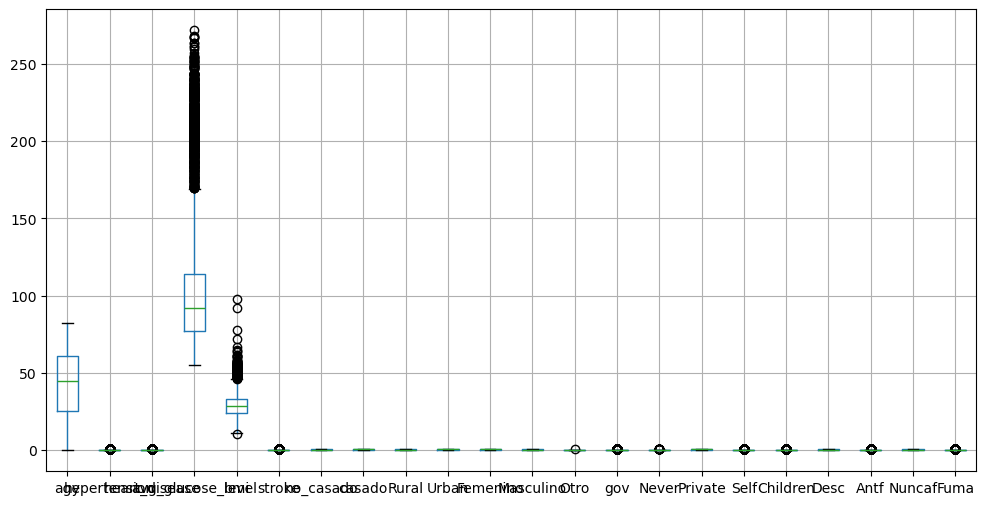

In [84]:
import matplotlib.pyplot as plt
df.boxplot(figsize=(12, 6))
plt.show()


Escalarización de los datos

In [85]:
from sklearn.preprocessing import StandardScaler

In [86]:
X = df

In [87]:
X = StandardScaler().fit_transform(X)

In [88]:
X

array([[ 1.05143428, -0.32860186,  4.18503199, ...,  2.1849511 ,
        -0.7667743 , -0.42731326],
       [ 0.78607007, -0.32860186, -0.2389468 , ..., -0.45767615,
         1.30416474, -0.42731326],
       [ 1.62639008, -0.32860186,  4.18503199, ..., -0.45767615,
         1.30416474, -0.42731326],
       ...,
       [-0.36384151, -0.32860186, -0.2389468 , ..., -0.45767615,
         1.30416474, -0.42731326],
       [ 0.34379639, -0.32860186, -0.2389468 , ...,  2.1849511 ,
        -0.7667743 , -0.42731326],
       [ 0.03420481, -0.32860186, -0.2389468 , ..., -0.45767615,
        -0.7667743 , -0.42731326]], shape=(5110, 22))

In [89]:
df_Scaler = pd.DataFrame(X)

In [90]:
df_Scaler.head()

,0,1,2,3,4,5,6,7,8,9,...,12,13,14,15,16,17,18,19,20,21
0,1.051434,-0.328602,4.185032,2.706375,1.001234e+00,4.418381,-0.723884,0.723884,-0.984080,0.984080,...,-0.01399,-0.384111,-0.065756,0.864297,-0.436881,-0.394112,-0.658011,2.184951,-0.766774,-0.427313
1,0.786070,-0.328602,-0.238947,2.121559,4.615554e-16,4.418381,-0.723884,0.723884,1.016178,-1.016178,...,-0.01399,-0.384111,-0.065756,-1.157010,2.288955,-0.394112,-0.658011,-0.457676,1.304165,-0.427313
2,1.626390,-0.328602,4.185032,-0.005028,4.685773e-01,4.418381,-0.723884,0.723884,1.016178,-1.016178,...,-0.01399,-0.384111,-0.065756,0.864297,-0.436881,-0.394112,-0.658011,-0.457676,1.304165,-0.427313
3,0.255342,-0.328602,-0.238947,1.437358,7.154182e-01,4.418381,-0.723884,0.723884,-0.984080,0.984080,...,-0.01399,-0.384111,-0.065756,0.864297,-0.436881,-0.394112,-0.658011,-0.457676,-0.766774,2.340204
4,1.582163,3.043196,-0.238947,1.501184,-6.357112e-01,4.418381,-0.723884,0.723884,1.016178,-1.016178,...,-0.01399,-0.384111,-0.065756,-1.157010,2.288955,-0.394112,-0.658011,-0.457676,1.304165,-0.427313


In [91]:
df_Scaler.describe()

,0,1,2,3,4,5,6,7,8,9,...,12,13,14,15,16,17,18,19,20,21
count,5.110000e+03,5.110000e+03,5.110000e+03,5.110000e+03,5.110000e+03,5.110000e+03,5.110000e+03,5.110000e+03,5.110000e+03,5.110000e+03,...,5.110000e+03,5.110000e+03,5.110000e+03,5.110000e+03,5.110000e+03,5.110000e+03,5.110000e+03,5.110000e+03,5.110000e+03,5.110000e+03
mean,5.005781e-17,-4.727682e-17,5.561978e-18,1.001156e-16,2.224791e-17,2.224791e-17,6.118176e-17,-6.118176e-17,-9.733462e-18,-9.177264e-17,...,-8.342968e-18,3.059088e-17,-1.042871e-17,-1.529544e-16,-6.396275e-17,-1.390495e-18,-4.727682e-17,3.615286e-17,-6.396275e-17,-3.754335e-17
std,1.000098e+00,1.000098e+00,1.000098e+00,1.000098e+00,1.000098e+00,1.000098e+00,1.000098e+00,1.000098e+00,1.000098e+00,1.000098e+00,...,1.000098e+00,1.000098e+00,1.000098e+00,1.000098e+00,1.000098e+00,1.000098e+00,1.000098e+00,1.000098e+00,1.000098e+00,1.000098e+00
min,-1.908261e+00,-3.286019e-01,-2.389468e-01,-1.126958e+00,-2.415564e+00,-2.263273e-01,-7.238842e-01,-1.381436e+00,-9.840797e-01,-1.016178e+00,...,-1.399046e-02,-3.841106e-01,-6.575636e-02,-1.157010e+00,-4.368805e-01,-3.941122e-01,-6.580107e-01,-4.576761e-01,-7.667743e-01,-4.273133e-01
25%,-8.061152e-01,-3.286019e-01,-2.389468e-01,-6.383223e-01,-6.616944e-01,-2.263273e-01,-7.238842e-01,-1.381436e+00,-9.840797e-01,-1.016178e+00,...,-1.399046e-02,-3.841106e-01,-6.575636e-02,-1.157010e+00,-4.368805e-01,-3.941122e-01,-6.580107e-01,-4.576761e-01,-7.667743e-01,-4.273133e-01
50%,7.843218e-02,-3.286019e-01,-2.389468e-01,-3.149945e-01,-6.407951e-02,-2.263273e-01,-7.238842e-01,7.238842e-01,-9.840797e-01,9.840797e-01,...,-1.399046e-02,-3.841106e-01,-6.575636e-02,8.642966e-01,-4.368805e-01,-3.941122e-01,-6.580107e-01,-4.576761e-01,-7.667743e-01,-4.273133e-01
75%,7.860701e-01,-3.286019e-01,-2.389468e-01,1.754080e-01,5.075521e-01,-2.263273e-01,1.381436e+00,7.238842e-01,1.016178e+00,9.840797e-01,...,-1.399046e-02,-3.841106e-01,-6.575636e-02,8.642966e-01,-4.368805e-01,-3.941122e-01,1.519732e+00,-4.576761e-01,1.304165e+00,-4.273133e-01
max,1.714845e+00,3.043196e+00,4.185032e+00,3.657145e+00,8.926127e+00,4.418381e+00,1.381436e+00,7.238842e-01,1.016178e+00,9.840797e-01,...,7.147727e+01,2.603417e+00,1.520765e+01,8.642966e-01,2.288955e+00,2.537348e+00,1.519732e+00,2.184951e+00,1.304165e+00,2.340204e+00


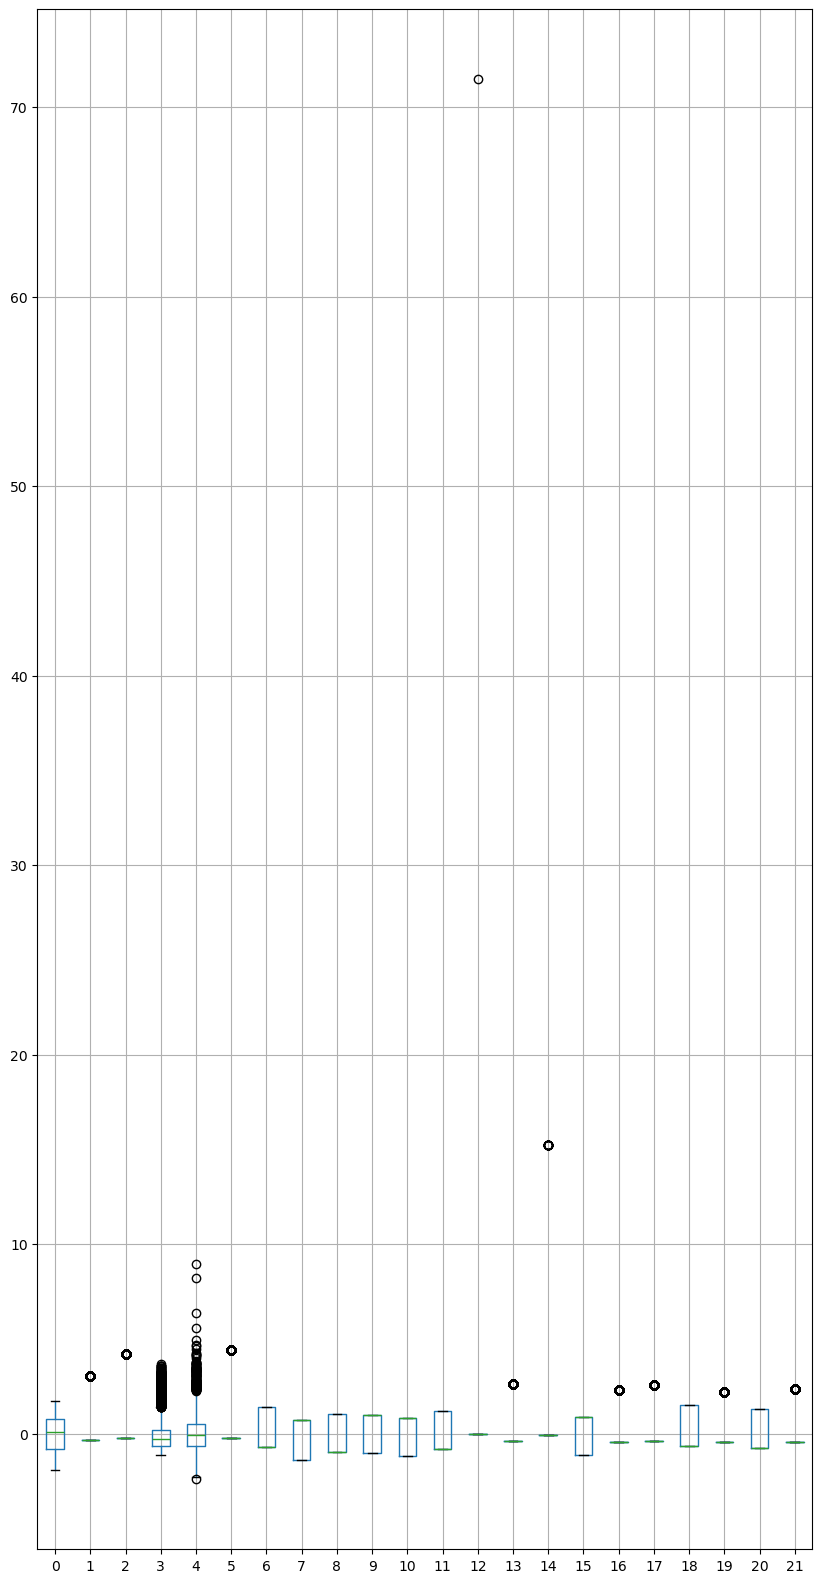

In [95]:
df_Scaler.boxplot(figsize=(10, 20))
plt.show()